In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import sys
import cv2

sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt
import random

# Object classification through time
## Single Image

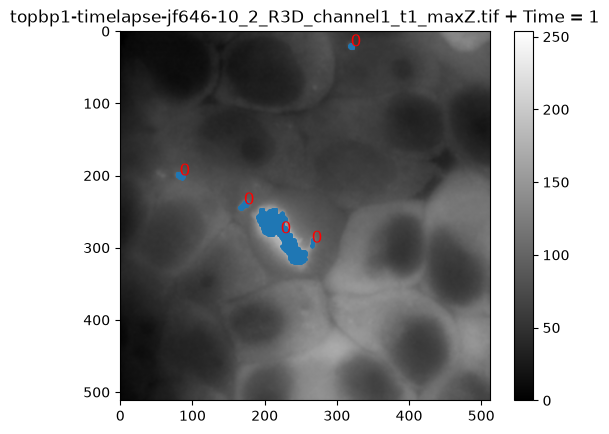

In [28]:
Image = CV_func.load_image("timelapze_z", number = 1, channel = 1)
Image.blur(ksize = (5, 5), sigma = 1.4)
Image.normalize()
C = -int(Image.array.mean()*0.3)
Image.adaptive_threshold(block_size = 101, C = C)
marked_points = CV_func.get_marked_points(Image.th)
segments = CV_func.region_growing(Image.th, marked_points, min_size = 10)
for j in range(len(segments)):
    Segment = CV_class.Segment(segments[j], Image)
    Image.segments.append(Segment)
    Segment.assign_label(Image)

Image.display(show_segments=True)

## Multiple images
So here i created the segment class. 

In [141]:
# We load multiple images
N_images = 25
Image_array_1 = np.array([], dtype = object)
for i in range(N_images):
    Image_array_1 = np.append(Image_array_1, CV_func.load_image("timelapze_z", number = i+1, channel = 1))


for i in range(N_images):

    C_factor = 0.3
    block_size = 101
    # Select and preprocess
    Image = Image_array_1[i]
    Image.blur(ksize = (5, 5), sigma = 1.4)
    Image.normalize()

    # Thresholding
    C = -int(Image.array.mean()*C_factor)
    Image.adaptive_threshold(block_size = block_size, C = C)

    # Segment
    marked_points = CV_func.get_marked_points(Image.th)
    found_segments = CV_func.region_growing(Image.th, marked_points, min_size = 15)

    # Create segment classes and add them to the image's segment list. also label them
    for j in range(len(found_segments)):
        Segment = CV_class.Segment(found_segments[j], Image)
        if i == 0:
            Segment.label = j+1

        Image.add_segment(Segment)

    # Assign labels to the segments based on the previous image
    if i > 0:
        for segment in Image.segments:
            segment.assign_label(Image_array_1[i - 1], max_range = 20)

CV_func.interactive_plot(Image_array_1)

interactive(children=(IntSlider(value=0, description='i', max=24), Output()), _dom_classes=('widget-interact',…

### Channel 2

In [146]:
N_images = 25

Image_array_2 = np.array([], dtype = object)
for i in range(N_images):
    Image_array_2 = np.append(Image_array_2, CV_func.load_image("timelapze_z", number = i+1, channel = 2))

C_factor = 0.05
block_size = 51
for i in range(len(Image_array_2)):
    Image = Image_array_2[i]

    # Crop to the size of the largest segment of the channel 1 image
    Image_channel_1 = Image_array_1[i]
    min_y, max_y, min_x, max_x = Image_channel_1.largest_segment.get_bounding_box(scale = 1)

    Image.crop_from_original(min_y, max_y, min_x, max_x)

    # Thresholding
    C = -int(Image.array.mean()*C_factor)
    Image.adaptive_threshold(block_size = block_size, C = C)

    # Segment
    marked_points = CV_func.get_marked_points(Image.th)
    found_segments = CV_func.region_growing(Image.th, marked_points, min_size = 5)

    # Create segment classes and add them to the image's segment list. also label them
    for j in range(len(found_segments)):
        Segment = CV_class.Segment(found_segments[j], Image)
        if i == 0:
            Segment.label = j+1

        Image.add_segment(Segment)

    # Assign labels to the segments based on the previous image
    if i > 0:
        for segment in Image.segments:
            segment.assign_label(Image_array_2[i - 1], max_range = 1)

CV_func.interactive_plot(Image_array_2)


interactive(children=(IntSlider(value=0, description='i', max=24), Output()), _dom_classes=('widget-interact',…